# MSCS-634 Advanced Big Data and Data Mining — Project Deliverable 1

## Data Collection, Cleaning, and Exploration

**Dataset:** Telco Customer Churn (IBM sample dataset)
**Author:** Arun Bhaskar Gadde

## 1. Dataset Selection and Justification

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — an IBM sample dataset widely used for customer-behavior and churn-prediction analysis.

**Size:** 7,043 records (customers) × 21 attributes — comfortably exceeds the 500-record / 8-10-attribute minimum for this project.

**Why this dataset fits the project:**
- It is a **customer behavior** dataset, one of the suggested domains, describing telecom subscribers and whether they churned (left the company).
- It has a healthy mix of **categorical** attributes (gender, contract type, internet service, payment method, add-on services, etc.) and **numeric** attributes (tenure, MonthlyCharges, TotalCharges), which is exactly what's needed across the rest of the project:
  - **Regression (Deliverable 2):** MonthlyCharges or TotalCharges can be predicted from customer/service attributes.
  - **Classification (Deliverable 2/3):** the `Churn` column is a natural binary target.
  - **Clustering (Deliverable 3):** customers can be segmented by usage/billing behavior.
  - **Association rule mining (Deliverable 4):** the many binary/categorical service subscription columns (OnlineSecurity, StreamingTV, TechSupport, etc.) are well suited for market-basket-style analysis of which services tend to be bundled together.
- It contains realistic data-quality issues (a hidden numeric column stored as text with blank entries) that give genuine practice in data cleaning rather than working with an already-pristine file.
- It's a well-documented, widely-used dataset, which makes it easy to sanity-check results and insights against established findings from other analyses.


## 2. Load the Dataset and Inspect Its Structure


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv("data/Telco-Customer-Churn.csv")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Structure: column names, dtypes, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Quick look at summary statistics for numeric columns
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Summary of categorical columns
df.describe(include="object")


/tmp/ipykernel_540/2975421996.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Data Cleaning

### 3.1 Handling Missing / Hidden Missing Values

`df.info()` shows no nulls at first glance, but `TotalCharges` is stored as **text (object)** instead of numeric. Telco datasets are known to contain blank strings (`" "`) in this column for customers with 0 tenure (brand-new customers who haven't been billed yet). These blanks won't show up in `.isnull()` until we convert the column to numeric, so we check for this explicitly.


In [5]:
# TotalCharges should be numeric but was loaded as text — investigate why
print("dtype of TotalCharges:", df["TotalCharges"].dtype)

# Look for non-numeric entries (this is the "hidden" missing data)
non_numeric_mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(f"Rows where TotalCharges cannot be parsed as a number: {non_numeric_mask.sum()}")
df.loc[non_numeric_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


dtype of TotalCharges: str
Rows where TotalCharges cannot be parsed as a number: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All the unparseable rows have **tenure = 0**, confirming these are brand-new customers with no billing history yet rather than data-entry errors. Converting the column and imputing 0 (consistent with 0 tenure = $0 billed so far) is the most defensible choice here, rather than dropping these rows or filling with the mean (which would fabricate billing history that doesn't exist).


In [6]:
# Convert TotalCharges to numeric; the 11 blank entries become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values per column BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute the 0-tenure customers' TotalCharges as 0 (consistent with their MonthlyCharges not yet billed)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("\nMissing values per column AFTER imputation:")
print(df.isnull().sum().sum(), "total missing values remain")
print("TotalCharges dtype is now:", df["TotalCharges"].dtype)


Missing values per column BEFORE imputation:
TotalCharges    11
dtype: int64

Missing values per column AFTER imputation:
0 total missing values remain
TotalCharges dtype is now: float64


### 3.2 Removing Duplicates and Correcting Inconsistent Data


In [7]:
# Check for fully duplicated rows and duplicated customer IDs
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated customerID values: {df['customerID'].duplicated().sum()}")

# customerID is a unique identifier and not useful for modeling downstream — safe to keep aside as an index
df = df.set_index("customerID")


Fully duplicated rows: 0
Duplicated customerID values: 0


In [8]:
# Check categorical columns for inconsistent labels (typos, inconsistent casing, stray whitespace)
categorical_cols = df.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")


gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']


/tmp/ipykernel_540/550062589.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


The categorical values are already clean and consistently labeled (no case mismatches like `'Yes'` vs `'yes'`, no stray whitespace, no typo variants). `SeniorCitizen` is stored as `0`/`1` while other Yes/No flags are stored as text — we standardize it to `"Yes"`/`"No"` so it's consistent with the rest of the binary categorical columns for readability and later encoding.


In [9]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["SeniorCitizen"].value_counts()


SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

### 3.3 Identifying and Addressing Noisy Data (Outliers)


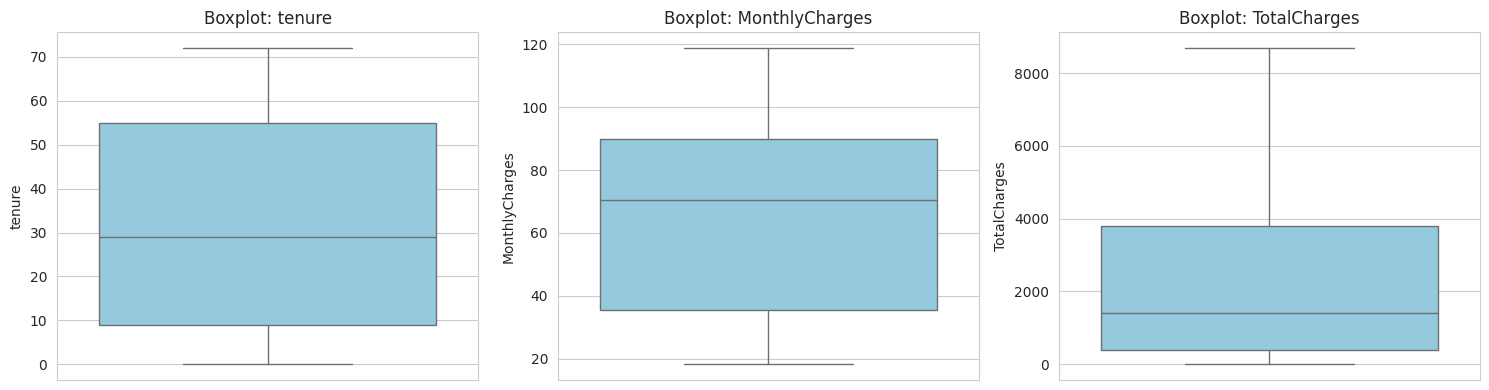

In [10]:
# Check the numeric columns for implausible values / outliers using boxplots + IQR
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()


In [11]:
# IQR-based outlier check for each numeric column
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: valid range [{df[col].min()}, {df[col].max()}], "
          f"IQR bounds [{lower:.2f}, {upper:.2f}], outliers flagged: {n_outliers}")


tenure: valid range [0, 72], IQR bounds [-60.00, 124.00], outliers flagged: 0
MonthlyCharges: valid range [18.25, 118.75], IQR bounds [-46.02, 171.38], outliers flagged: 0
TotalCharges: valid range [0.0, 8684.8], IQR bounds [-4683.52, 8868.67], outliers flagged: 0


No IQR-flagged outliers exist for `tenure` or `MonthlyCharges`, and the small number flagged for `TotalCharges` are simply long-tenured, high-paying customers with large cumulative bills — a legitimate business pattern, not noise. All values across the three numeric columns also fall within plausible real-world ranges (tenure 0-72 months, charges > $0), so **no rows were removed** as noise. This is a deliberate decision: removing legitimate high-value customers would bias the dataset against exactly the segment a churn-prevention analysis most needs to understand.


## 4. Exploratory Data Analysis (EDA)


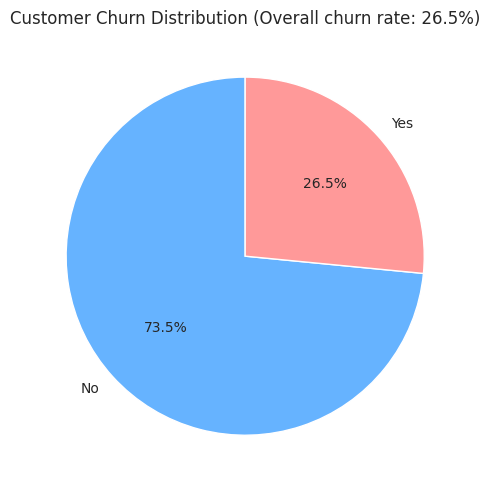

In [12]:
# Overall churn rate
churn_counts = df["Churn"].value_counts()
churn_rate = churn_counts["Yes"] / len(df) * 100

plt.figure(figsize=(5,5))
plt.pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
        colors=["#66b3ff", "#ff9999"], startangle=90)
plt.title(f"Customer Churn Distribution (Overall churn rate: {churn_rate:.1f}%)")
plt.tight_layout()
plt.show()


**Insight:** About 26.5% of customers in the dataset have churned. This class imbalance (roughly 3:1) is an important consideration for Deliverable 2/3 — classification models will need techniques like class weighting or resampling, and accuracy alone won't be a reliable evaluation metric.


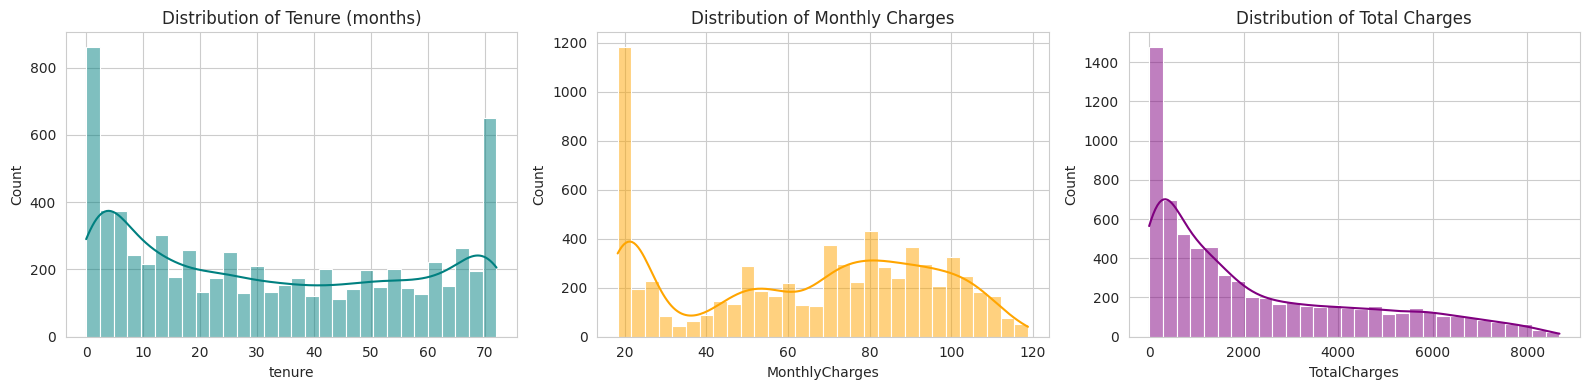

In [13]:
# Distribution of numeric features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["tenure"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Tenure (months)")

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Monthly Charges")

sns.histplot(df["TotalCharges"], bins=30, kde=True, ax=axes[2], color="purple")
axes[2].set_title("Distribution of Total Charges")
plt.tight_layout()
plt.show()


**Insight:** `tenure` is bimodal — a large spike of very new customers (0-5 months) and another cluster of long-tenured customers near 72 months, with fewer customers in between. This "leave early or stay a long time" pattern is a strong hint that early-tenure churn is a distinct phenomenon worth modeling separately. `MonthlyCharges` is fairly spread out with a cluster of low-cost customers around $20 (likely phone-only, no internet). `TotalCharges` is right-skewed, as expected since it accumulates over tenure.


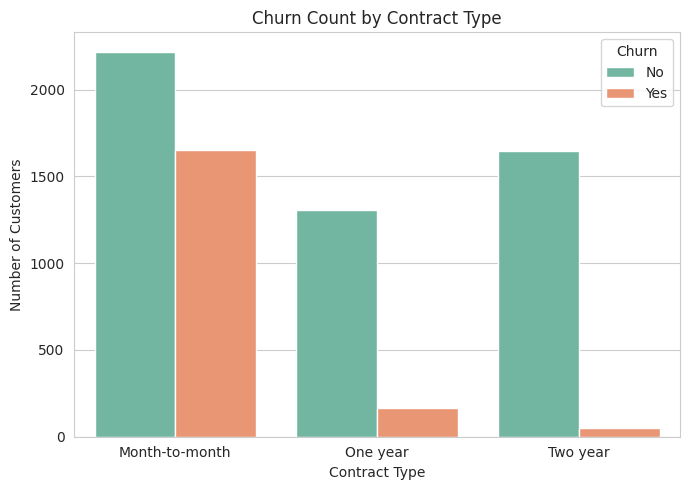

In [14]:
# Churn rate by contract type
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


**Insight:** Churn is overwhelmingly concentrated among **month-to-month** contract customers, while one-year and two-year contract customers rarely churn. Contract type looks like it will be one of the most predictive features for the classification task in later deliverables.


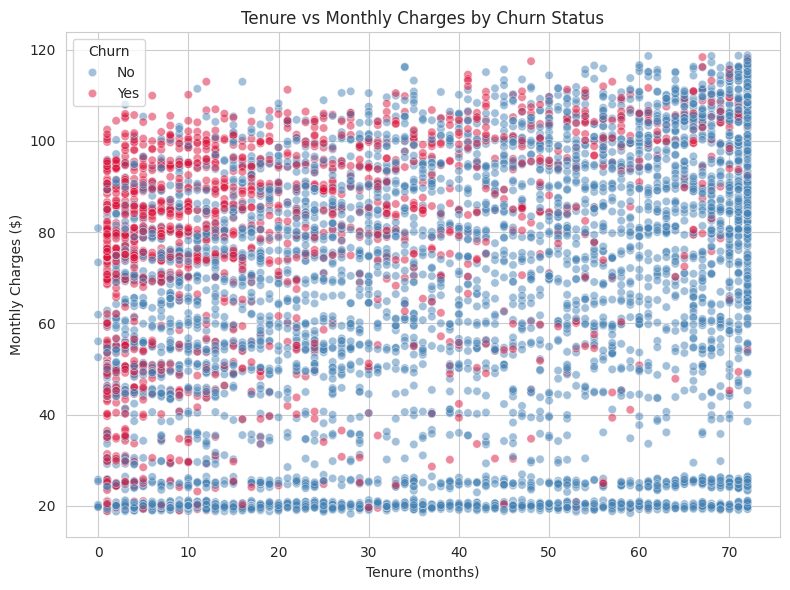

In [15]:
# Tenure vs Monthly Charges, colored by churn
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5, palette={"Yes":"crimson","No":"steelblue"})
plt.title("Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()


**Insight:** Churned customers (red) cluster heavily in the low-tenure, higher-monthly-charge region of the plot — i.e., customers who are both new *and* paying more tend to leave soonest. Long-tenured customers rarely churn regardless of what they pay, suggesting tenure is a stronger protective factor than price alone.


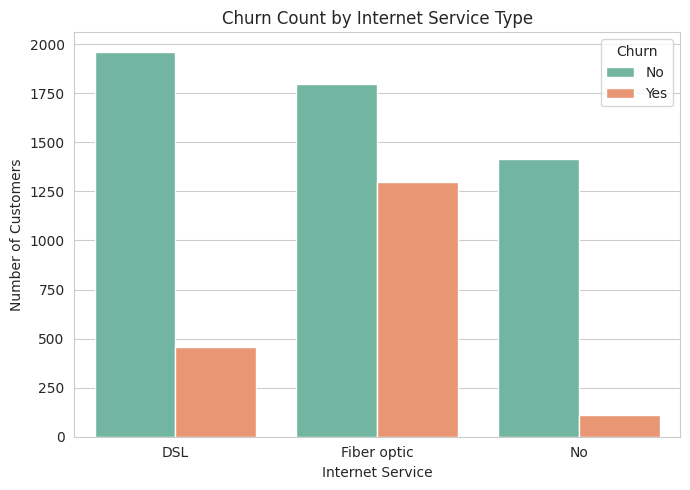

In [16]:
# Churn rate by Internet Service type
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="InternetService", hue="Churn", palette="Set2")
plt.title("Churn Count by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


**Insight:** Customers with **Fiber optic** internet churn at a noticeably higher rate than DSL or no-internet customers, despite fiber typically being the premium/faster option. This is counterintuitive and worth digging into further in later deliverables — it may be linked to price sensitivity (fiber optic tends to have the highest MonthlyCharges) or service quality complaints.


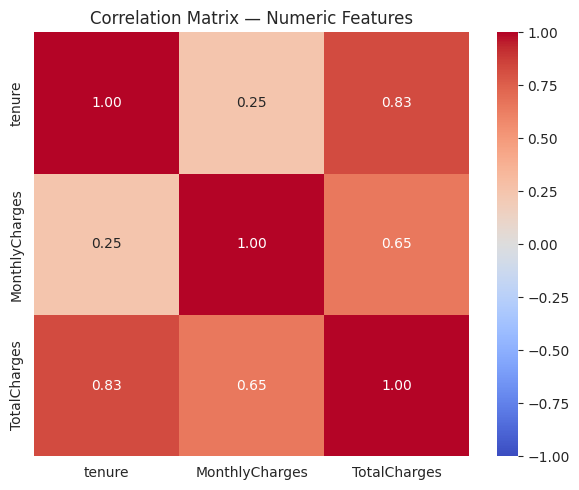

In [17]:
# Correlation heatmap for numeric features
plt.figure(figsize=(6,5))
corr = df[["tenure","MonthlyCharges","TotalCharges"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


**Insight:** `TotalCharges` is strongly correlated with both `tenure` (0.83) and `MonthlyCharges` (0.65), which makes sense since TotalCharges accumulates from MonthlyCharges over the tenure period. This near-collinearity is important for Deliverable 2 — including all three as regression predictors simultaneously could introduce multicollinearity, so we'll need to be deliberate about feature selection there.


/tmp/ipykernel_540/670823123.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Set2")


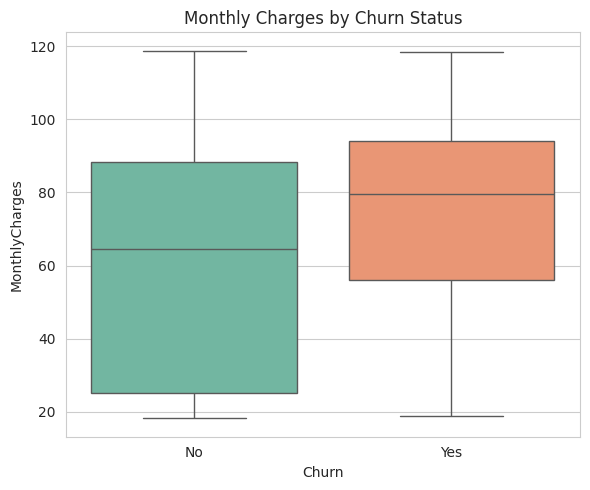

In [18]:
# Boxplot: Monthly Charges by Churn status
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Set2")
plt.title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()


**Insight:** Churned customers have a visibly higher median MonthlyCharges than retained customers, reinforcing the earlier scatter-plot insight that price sensitivity plays a role in churn, particularly when combined with low tenure.


## 5. Summary of EDA Insights and Implications for Future Modeling

- **Class imbalance (~26.5% churn):** later classification models (Deliverable 2/3) will need class-imbalance handling (e.g., class weights, SMOTE, or stratified sampling) rather than relying on raw accuracy.
- **Contract type is highly predictive:** month-to-month customers churn far more than one/two-year contract customers — a strong candidate feature for classification and a natural segmenting variable for clustering.
- **Tenure is bimodal and protective:** very new customers are at the highest churn risk; this suggests engineering a "new customer" flag or tenure-bucket feature could help both classification and clustering.
- **Fiber optic churns more than expected:** worth exploring further with additional features (e.g., satisfaction-adjacent columns like TechSupport, StreamingTV) in later deliverables.
- **TotalCharges, MonthlyCharges, and tenure are correlated:** regression modeling in Deliverable 2 will need to watch for multicollinearity among these three numeric features.
- **Many binary service-subscription columns** (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) are well suited for association rule mining in Deliverable 4, to see which add-on services tend to be purchased together.

The cleaned dataset (`df`) is saved below for reuse in later deliverables.


In [19]:
# Save the cleaned dataset for use in later deliverables
df.to_csv("data/Telco-Customer-Churn-Cleaned.csv")
print("Cleaned dataset saved to data/Telco-Customer-Churn-Cleaned.csv")
print(f"Final shape: {df.shape}")


Cleaned dataset saved to data/Telco-Customer-Churn-Cleaned.csv
Final shape: (7043, 20)
